# Регуляризация

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv('Advertising.csv')
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [3]:
X = df.drop('sales', axis=1)
y = df['sales']

In [4]:
from sklearn.preprocessing import PolynomialFeatures

pol_converter = PolynomialFeatures(degree=3, include_bias=False)
pol_features = pol_converter.fit_transform(X)
pol_features.shape

(200, 19)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(pol_features, y, test_size=0.33, random_state=101)
X_train.shape

(134, 19)

---
## Маштабирование 

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

scaled_X_train = scaler.transform(X_train)
scaled_X_train[0]

array([ 0.455913  , -0.15469995, -0.98899258,  0.23144458,  0.12990319,
       -0.57856073, -0.43655678, -0.66806654, -0.71668198,  0.02389419,
        0.04869878, -0.45436665, -0.22089285, -0.47664217, -0.51504813,
       -0.55818067, -0.60618091, -0.56426029, -0.5063835 ])

---
## L2 - Регуляризация. (Ridge)

In [7]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

ridge_model = Ridge(alpha=10)
ridge_model.fit(X_train,y_train)

y_pred = ridge_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'MAE: {mae:.3f}')
print(f'MSE: {mse:.3f}')
print(f'RMSE: {rmse:.3f}')

MAE: 0.393
MSE: 0.311
RMSE: 0.558


---
## Регуляризация с Кросс-валидацией

In [8]:
from sklearn.linear_model import RidgeCV

ridge_cv_model = RidgeCV(alphas=(0.1, 1.0, 10.0), scoring='neg_mean_absolute_error')
ridge_cv_model.fit(X_train, y_train)

y_pred = ridge_cv_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'MAE: {mae:.3f}')
print(f'MSE: {mse:.3f}')
print(f'RMSE: {rmse:.3f}')

ridge_cv_model.coef_

MAE: 1.670
MSE: 4.208
RMSE: 2.051


array([ 8.47536583e-02,  2.98946231e-02,  1.44484821e-02, -4.06659659e-04,
        1.56002789e-03, -3.12583900e-04, -1.76404543e-03,  9.23685743e-04,
        1.47306388e-04,  4.20928700e-07, -1.76604954e-06,  1.00699253e-06,
        2.76313222e-06, -2.16978515e-06,  4.50381776e-08,  2.17500574e-05,
       -8.10652045e-06, -3.60551712e-06, -1.21128869e-06])

In [9]:
ridge_cv_model.alpha_

np.float64(10.0)

In [10]:
ridge_cv_model.best_score_

-0.37644005038860173

--- 
## L1 - Регуляризация. (Lasso)

In [11]:
from sklearn.linear_model import Lasso, LassoCV

In [12]:
lasso_cv_model = LassoCV(eps=0.001, n_alphas=100, cv=5)
lasso_cv_model.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


,eps,0.001
,n_alphas,100
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,copy_X,True
,cv,5
,verbose,False
,n_jobs,None


In [13]:
lasso_cv_model.coef_

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  9.73624041e-08,  3.48014469e-06, -1.97597479e-07,
        1.10050893e-05,  0.00000000e+00,  0.00000000e+00, -0.00000000e+00,
       -0.00000000e+00, -0.00000000e+00, -0.00000000e+00])

In [14]:
lasso_cv_model.alpha_

np.float64(22797.431024353526)

In [15]:
y_pred = lasso_cv_model.predict(X_test)

In [16]:
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'MAE: {mae:.3f}')
print(f'MSE: {mse:.3f}')
print(f'RMSE: {rmse:.3f}')

MAE: 1.294
MSE: 3.415
RMSE: 1.848


--- 
## Elastic Net 

In [17]:
from sklearn.linear_model import ElasticNetCV

In [18]:
elastic_model = ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1], eps=0.001, n_alphas=100, max_iter=10000000)
elastic_model.fit(X_train, y_train)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(


,l1_ratio,"[0.1, 0.5, ...]"
,eps,0.001
,n_alphas,100
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,10000000
,tol,0.0001
,cv,None
,copy_X,True
,verbose,0


In [19]:
elastic_model.alpha_

np.float64(22797.431024353526)

In [20]:
elastic_model.coef_

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  9.73624041e-08,  3.48014469e-06, -1.97597479e-07,
        1.10050893e-05,  0.00000000e+00,  0.00000000e+00, -0.00000000e+00,
       -0.00000000e+00, -0.00000000e+00, -0.00000000e+00])

In [21]:
elastic_model.l1_ratio_

np.float64(1.0)

In [22]:
y_pred = elastic_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f'MAE: {mae:.3f}')
print(f'MSE: {mse:.3f}')
print(f'RMSE: {rmse:.3f}')

MAE: 1.294
MSE: 3.415
RMSE: 1.848


In [23]:
%pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.5/555.5 kB 2.4 MB/s  0:00:0036m-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 10.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.2/37.2 MB 1.1 MB/s  0:00:30m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]4/5 [shap]]te]
Note: you may need to restart the kernel to use updated packages.


In [30]:
X_train.shape

(134, 19)

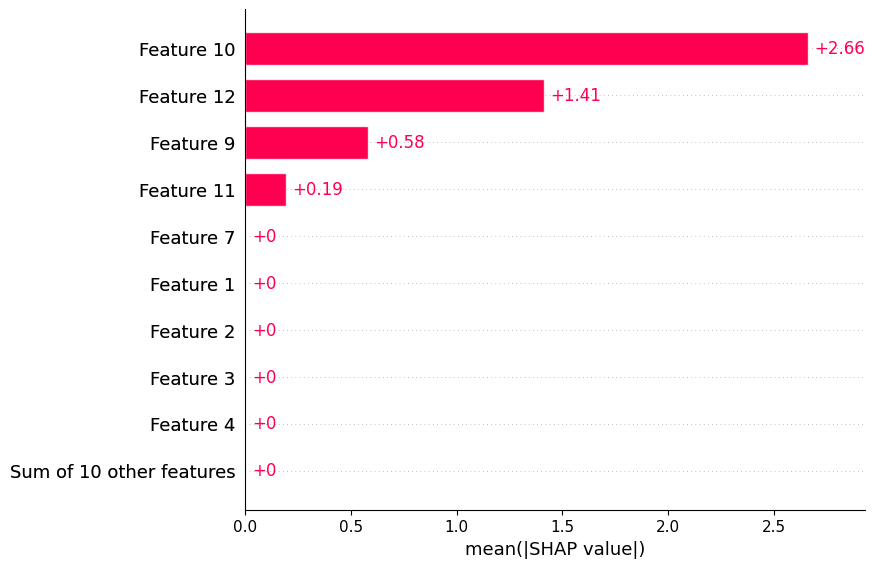

.values =
array([[-0.,  0.,  0., ..., -0., -0., -0.],
       [ 0.,  0., -0., ...,  0.,  0.,  0.],
       [-0., -0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ..., -0., -0., -0.],
       [ 0., -0.,  0., ...,  0.,  0., -0.],
       [ 0.,  0.,  0., ..., -0., -0., -0.]], shape=(66, 19))

.base_values =
array([14.1828517, 14.1828517, 14.1828517, 14.1828517, 14.1828517,
       14.1828517, 14.1828517, 14.1828517, 14.1828517, 14.1828517,
       14.1828517, 14.1828517, 14.1828517, 14.1828517, 14.1828517,
       14.1828517, 14.1828517, 14.1828517, 14.1828517, 14.1828517,
       14.1828517, 14.1828517, 14.1828517, 14.1828517, 14.1828517,
       14.1828517, 14.1828517, 14.1828517, 14.1828517, 14.1828517,
       14.1828517, 14.1828517, 14.1828517, 14.1828517, 14.1828517,
       14.1828517, 14.1828517, 14.1828517, 14.1828517, 14.1828517,
       14.1828517, 14.1828517, 14.1828517, 14.1828517, 14.1828517,
       14.1828517, 14.1828517, 14.1828517, 14.1828517, 14.1828517,
       14.1

In [ ]:
import shap

explainer = shap.Explainer(elastic_model, X_train)
shap_values = explainer(X_test)

# глобальная важность
shap.plots.bar(shap_values)
# распределение вкладов
shap.plots.beeswarm(shap_values)
# локальное объяснение
shap.plots.waterfall(shap_values[0])

print(shap_values)

In [33]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    elastic_model,
    X_test,
    y_test,
    scoring='r2',
    n_repeats=20,
    random_state=42
)
impotances = result.importances_mean
impotances

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 2.77918000e-02, 7.03584178e-01, 5.31579357e-04,
       2.06891056e-01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00])